<a href="https://colab.research.google.com/github/SmitPatil2004/traffic-forecasting-uct/blob/main/01_traffic_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from google.colab import drive
drive.mount('/content/drive/MyDrive')

ValueError: Mountpoint must be in a directory that exists

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('train_aWnotuB.csv')   # ← use YOUR exact filename
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [14]:
print('Shape:', df.shape)
print('\nColumn types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nRows per junction:\n', df['Junction'].value_counts().sort_index())
print('\nVehicles summary:\n', df['Vehicles'].describe())

Shape: (48120, 4)

Column types:
 DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object

Missing values:
 DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Duplicate rows: 0

Rows per junction:
 Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

Vehicles summary:
 count    48120.000000
mean        22.791334
std         20.750063
min          1.000000
25%          9.000000
50%         15.000000
75%         29.000000
max        180.000000
Name: Vehicles, dtype: float64


In [15]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

print('Date range:', df['DateTime'].min(), '→', df['DateTime'].max())

df['Hour']      = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['Month']     = df['DateTime'].dt.month
df['Year']      = df['DateTime'].dt.year
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

df.head()

Date range: 2015-11-01 00:00:00 → 2017-06-30 23:00:00


,DateTime,Junction,Vehicles,ID,Hour,DayOfWeek,Month,Year,IsWeekend
0,2015-11-01 00:00:00,1,15,20151101001,0,6,11,2015,1
1,2015-11-01 01:00:00,1,13,20151101011,1,6,11,2015,1
2,2015-11-01 02:00:00,1,10,20151101021,2,6,11,2015,1
3,2015-11-01 03:00:00,1,7,20151101031,3,6,11,2015,1
4,2015-11-01 04:00:00,1,9,20151101041,4,6,11,2015,1


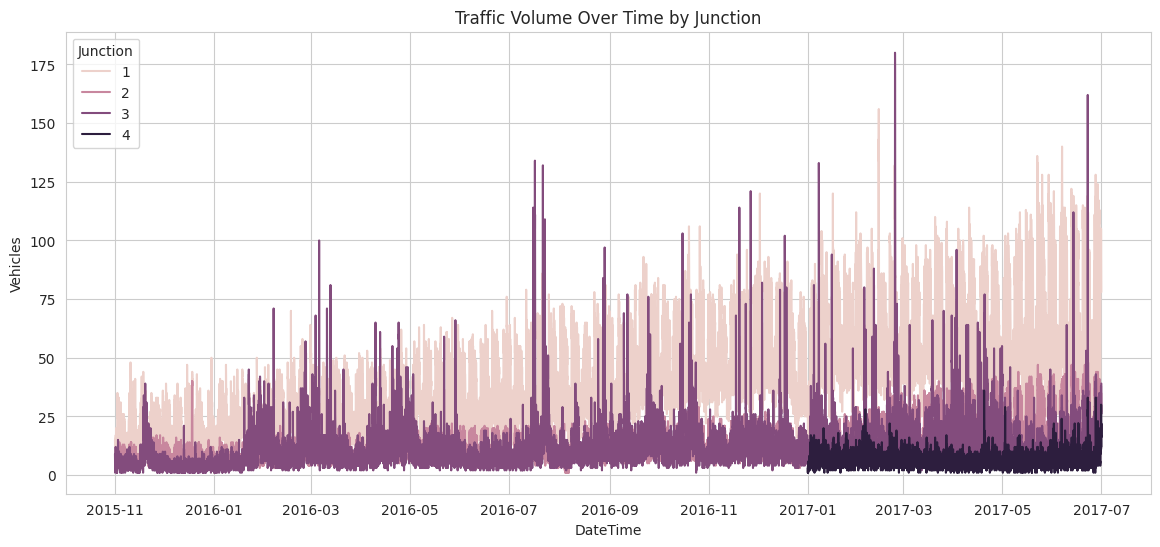

In [16]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x='DateTime', y='Vehicles', hue='Junction')
plt.title('Traffic Volume Over Time by Junction')
plt.savefig('01_traffic_over_time.png', dpi=120, bbox_inches='tight')
plt.show()

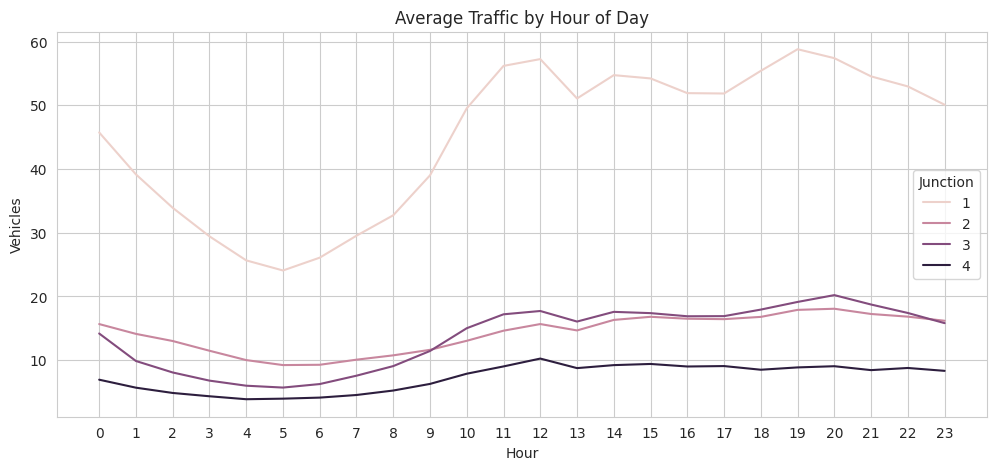

In [17]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='Hour', y='Vehicles', hue='Junction', errorbar=None)
plt.title('Average Traffic by Hour of Day')
plt.xticks(range(0, 24))
plt.savefig('02_traffic_by_hour.png', dpi=120, bbox_inches='tight')
plt.show()

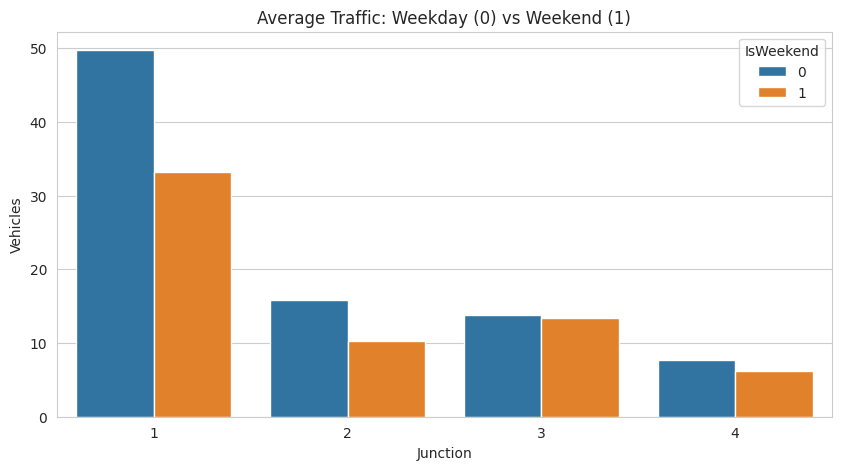

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Junction', y='Vehicles', hue='IsWeekend', errorbar=None)
plt.title('Average Traffic: Weekday (0) vs Weekend (1)')
plt.savefig('03_weekday_vs_weekend.png', dpi=120, bbox_inches='tight')
plt.show()

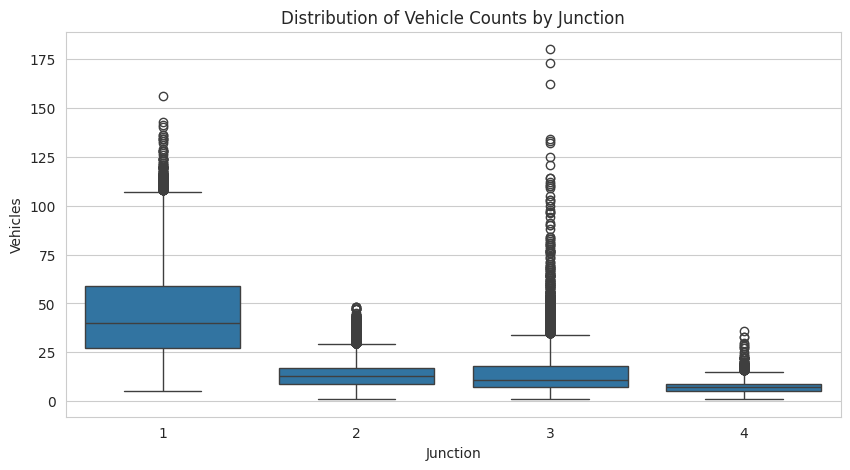

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Junction', y='Vehicles')
plt.title('Distribution of Vehicle Counts by Junction')
plt.savefig('04_junction_distribution.png', dpi=120, bbox_inches='tight')
plt.show()